# Ingesta inicial de datos: Orange Book y Drugs@FDA

## Objetivo 

El objetivo de este notebook es construir la primera base de trabajo para el proyecto:

**Patentes, exclusividades y tiempo a genéricos: un modelo de riesgo**

En esta etapa no se ajustarán todavía modelos estadísticos. El propósito principal es leer, revisar, limpiar y organizar los archivos descargados de dos fuentes públicas de la FDA:

1. **Orange Book Data Files**
2. **Drugs@FDA Data Files**

A partir de estas fuentes se construirá una base preliminar que permita, en notebooks posteriores, estudiar el tiempo transcurrido desde la aprobación inicial de un medicamento innovador hasta la entrada de su primer genérico.


## Fuentes de datos

### 1. Orange Book Data Files

El **Orange Book** es una base publicada por la FDA que contiene información sobre productos farmacéuticos aprobados, equivalencia terapéutica, patentes y exclusividades regulatorias.

Para este proyecto se descargó el archivo comprimido disponible en la página de **Orange Book Data Files**. Al descomprimirlo se obtuvieron tres archivos principales:

- `products.txt`
- `patent.txt`
- `exclusivity.txt`

Estos archivos están en formato de texto delimitado por `~`.

#### `products.txt`

Este archivo contiene información a nivel de producto farmacéutico. Incluye variables como:

- ingrediente activo;
- forma farmacéutica y ruta de administración;
- nombre comercial;
- solicitante o empresa responsable;
- concentración;
- tipo de aplicación;
- número de aplicación FDA;
- número de producto;
- código de equivalencia terapéutica;
- fecha de aprobación;
- indicador de Reference Listed Drug;
- indicador de Reference Standard;
- tipo de producto: prescripción, OTC o descontinuado.

En este proyecto, `products.txt` será útil para distinguir entre productos innovadores y genéricos, así como para identificar productos con códigos de equivalencia terapéutica apropiados.

En particular, la variable de tipo de aplicación permite distinguir entre:

- `N`: New Drug Application, asociada usualmente a productos innovadores;
- `A`: Abbreviated New Drug Application, asociada usualmente a productos genéricos.

#### `patent.txt`

Este archivo contiene información sobre las patentes listadas para los productos aprobados. Incluye:

- tipo de aplicación;
- número de aplicación;
- número de producto;
- número de patente;
- fecha de expiración de la patente;
- indicadores sobre si la patente corresponde a sustancia activa, producto farmacéutico o uso;
- códigos de uso de patente;
- indicadores de solicitud de retiro de patente;
- fecha de envío de la información de patente.

En este proyecto, `patent.txt` permitirá construir variables relacionadas con la protección por patente, por ejemplo:

- existencia de patentes asociadas;
- número de patentes por aplicación;
- fecha mínima de expiración de patente;
- fecha máxima de expiración de patente;
- presencia de patentes de sustancia;
- presencia de patentes de producto;
- presencia de patentes de uso.

#### `exclusivity.txt`

Este archivo contiene información sobre exclusividades regulatorias otorgadas por la FDA. Incluye:

- tipo de aplicación;
- número de aplicación;
- número de producto;
- código de exclusividad;
- fecha de expiración de la exclusividad.

En este proyecto, `exclusivity.txt` permitirá identificar distintos tipos de protección regulatoria, tales como:

- exclusividad por nueva entidad química;
- exclusividad pediátrica;
- exclusividad por medicamento huérfano;
- otras exclusividades regulatorias.

Estas variables serán importantes para estudiar si ciertos tipos de exclusividad se asocian con mayores tiempos hasta la entrada de genéricos.



### 2. Drugs@FDA Data Files

**Drugs@FDA** es otra base pública de la FDA que contiene información histórica sobre aplicaciones, productos, aprobaciones, documentos regulatorios, estatus de comercialización y envíos asociados a medicamentos aprobados.

Para este proyecto se descargó el archivo comprimido **Drugs@FDA Download File**. Al descomprimirlo se obtuvieron varios archivos de texto, entre ellos:

- `Applications.txt`
- `Products.txt`
- `Submissions.txt`
- `MarketingStatus.txt`
- `TE.txt`
- `ApplicationDocs.txt`
- tablas auxiliares de clasificación y catálogos.

Estos archivos están en formato de texto delimitado por tabulaciones.

#### `Applications.txt`

Contiene información general sobre las aplicaciones registradas en Drugs@FDA. Este archivo será útil para identificar el tipo de aplicación, el número de aplicación y otros metadatos generales.

#### `Products.txt`

Contiene información de los productos asociados a cada aplicación. Será utilizado junto con los productos del Orange Book para armonizar nombres, ingredientes activos, formas farmacéuticas, rutas de administración y números de producto.

#### `Submissions.txt`

Contiene información sobre envíos regulatorios y acciones de aprobación. Este archivo es especialmente importante porque permite recuperar fechas de aprobación asociadas a aplicaciones y productos.

En este proyecto se utilizará para aproximar o confirmar la fecha de aprobación inicial de una aplicación NDA y, posteriormente, para identificar aprobaciones ANDA asociadas a genéricos.

#### `MarketingStatus.txt`

Contiene información sobre el estatus de comercialización de los productos. Puede ser útil para distinguir productos activos, descontinuados u otras situaciones regulatorias.

#### `TE.txt`

Contiene información de equivalencia terapéutica. Se usará para apoyar la identificación de genéricos terapéuticamente equivalentes al producto innovador.


## Llave principal de integración

La variable central para vincular los archivos será el número de aplicación FDA: `ApplNo`.



Durante la ingesta, será necesario normalizar esta variable para que tenga un formato homogéneo. Por ejemplo, se convertirá a texto, se eliminarán espacios y se completará con ceros a la izquierda cuando sea necesario:

```python
df["ApplNo"] = df["ApplNo"].astype(str).str.strip().str.zfill(6)

## Pregunta guía del proyecto

La pregunta general que se busca responder es:

**¿Cuánto tiempo transcurre desde la aprobación inicial de una nueva entidad molecular o producto innovador hasta la entrada de su primer genérico, y qué factores regulatorios o de producto se asocian con ese tiempo?**

Para responderla, en etapas posteriores se construirá una base de supervivencia con variables como:

- fecha de aprobación inicial del producto innovador;
- fecha del primer genérico equivalente;
- indicador de evento;
- tiempo hasta genérico;
- tipo de exclusividad;
- fechas de expiración de patentes;
- ruta de administración;
- forma farmacéutica;
- estatus de comercialización;
- código de equivalencia terapéutica.

Endpoint preliminar

El endpoint principal del proyecto será:

**T=tiempo desde la aprobación inicial del producto innovador hasta la aprobación del primer genérico equivalente**

Para cada producto innovador se definirá:

- event = 1 si se observa la aprobación de al menos un genérico equivalente;
- event = 0 si no se observa genérico hasta la fecha de corte del estudio.

En los casos sin genérico observado, el tiempo será censurado a la derecha en la fecha de corte del estudio.

## 1. Preparación del entorno y verificación de carpetas

En esta etapa trabajaremos con dos fuentes de datos:

- `drugsatfda/`: contiene las tablas descargadas desde Drugs@FDA.
- `orange_book/`: contiene las tablas descargadas desde Orange Book.

La verificación inicial es importante porque permite detectar errores comunes antes de comenzar la lectura de archivos, por ejemplo:

- nombres de carpetas distintos;
- archivos ubicados en otra ruta;
- diferencias entre mayúsculas y minúsculas;
- notebooks ejecutados desde un directorio distinto al esperado.

El resultado esperado de la celda siguiente es una lista de archivos disponibles en cada carpeta.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Ruta base del proyecto.

PROJECT_DIR = Path.cwd()

# Carpetas de datos crudos
DRUGS_AT_FDA_DIR = PROJECT_DIR / "drugsatfda"
ORANGE_BOOK_DIR = PROJECT_DIR / "orange_book"

# Carpetas de salida que usaremos 
DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"


print("\nArchivos en Drugs@FDA:")
if DRUGS_AT_FDA_DIR.exists():
    for file in sorted(DRUGS_AT_FDA_DIR.iterdir()):
        print(" -", file.name)

print("\nArchivos en Orange Book:")
if ORANGE_BOOK_DIR.exists():
    for file in sorted(ORANGE_BOOK_DIR.iterdir()):
        print(" -", file.name)


Archivos en Drugs@FDA:
 - ActionTypes_Lookup.txt
 - ApplicationDocs.txt
 - Applications.txt
 - ApplicationsDocsType_Lookup.txt
 - Join_Submission_ActionTypes_Lookup.txt
 - MarketingStatus.txt
 - MarketingStatus_Lookup.txt
 - Products.txt
 - SubmissionClass_Lookup.txt
 - SubmissionPropertyType.txt
 - Submissions.txt
 - TE.txt

Archivos en Orange Book:
 - exclusivity.txt
 - patent.txt
 - products.txt


## Lectura inicial de las tablas principales

En la siguiente celda se leerán los archivos principales de Orange Book y Drugs@FDA.

Los archivos de Orange Book están delimitados por el carácter `~`, mientras que los archivos de Drugs@FDA están delimitados por tabulaciones. Por esta razón se definirá una función auxiliar para leer archivos de texto indicando el separador correspondiente.

En esta primera lectura se usará `dtype=str` para conservar todas las columnas como texto. Esto es conveniente en bases regulatorias porque algunos identificadores, como los números de aplicación, pueden tener ceros a la izquierda. Si Python los interpreta como números enteros, esos ceros podrían perderse y después dificultar las uniones entre tablas.

El objetivo de la celda es cargar las tablas en memoria y mostrar un resumen con:

- nombre de la tabla;
- número de filas;
- número de columnas;
- nombres de columnas.

## Lectura inicial de las tablas principales

En la siguiente celda se leerán los archivos principales de Orange Book y Drugs@FDA.

Los archivos de Orange Book están delimitados por el carácter `~`, mientras que los archivos de Drugs@FDA están delimitados por tabulaciones. Por esta razón se definirá una función auxiliar para leer archivos de texto indicando el separador correspondiente.

En esta primera lectura se usará `dtype=str` para conservar todas las columnas como texto. Esto es conveniente en bases regulatorias porque algunos identificadores, como los números de aplicación, pueden tener ceros a la izquierda. Si Python los interpreta como números enteros, esos ceros podrían perderse y después dificultar las uniones entre tablas.

El objetivo de la celda es cargar las tablas en memoria y mostrar un resumen con:

- nombre de la tabla;
- número de filas;
- número de columnas;
- nombres de columnas.

Todavía no se realizará limpieza profunda; primero revisaremos la estructura original de los archivos.

In [4]:
# Lectura inicial de las tablas principales

def read_text_table(path, sep, encoding="latin1"):
    """
    Lee una tabla de texto conservando todas las columnas como texto.
    
    Parámetros
    ----------
    path : pathlib.Path
        Ruta del archivo.
    sep : str
        Separador del archivo.
    encoding : str
        Codificación del archivo. Se usa latin1 por robustez con archivos FDA.
        
    Retorna
    -------
    pandas.DataFrame
        Tabla leída como dataframe.
    """
    return pd.read_csv(
        path,
        sep=sep,
        dtype=str,
        encoding=encoding,
        low_memory=False
    )


# Orange Book

ob_products = read_text_table(ORANGE_BOOK_DIR / "products.txt", sep="~")
ob_patent = read_text_table(ORANGE_BOOK_DIR / "patent.txt", sep="~")
ob_exclusivity = read_text_table(ORANGE_BOOK_DIR / "exclusivity.txt", sep="~")



# Drugs@FDA

fda_applications = read_text_table(DRUGS_AT_FDA_DIR / "Applications.txt", sep="\t")
fda_products = read_text_table(DRUGS_AT_FDA_DIR / "Products.txt", sep="\t")
fda_submissions = read_text_table(DRUGS_AT_FDA_DIR / "Submissions.txt", sep="\t")
fda_marketing = read_text_table(DRUGS_AT_FDA_DIR / "MarketingStatus.txt", sep="\t")
fda_te = read_text_table(DRUGS_AT_FDA_DIR / "TE.txt", sep="\t")


# Resumen de estructura

tables = {
    "ob_products": ob_products,
    "ob_patent": ob_patent,
    "ob_exclusivity": ob_exclusivity,
    "fda_applications": fda_applications,
    "fda_products": fda_products,
    "fda_submissions": fda_submissions,
    "fda_marketing": fda_marketing,
    "fda_te": fda_te,
}

for name, df in tables.items():
    print("=" * 80)
    print(name)
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    print("Columnas:")
    print(list(df.columns))
    print()

ob_products
Filas: 48,083 | Columnas: 14
Columnas:
['Ingredient', 'DF;Route', 'Trade_Name', 'Applicant', 'Strength', 'Appl_Type', 'Appl_No', 'Product_No', 'TE_Code', 'Approval_Date', 'RLD', 'RS', 'Type', 'Applicant_Full_Name']

ob_patent
Filas: 20,858 | Columnas: 10
Columnas:
['Appl_Type', 'Appl_No', 'Product_No', 'Patent_No', 'Patent_Expire_Date_Text', 'Drug_Substance_Flag', 'Drug_Product_Flag', 'Patent_Use_Code', 'Delist_Flag', 'Submission_Date']

ob_exclusivity
Filas: 2,054 | Columnas: 5
Columnas:
['Appl_Type', 'Appl_No', 'Product_No', 'Exclusivity_Code', 'Exclusivity_Date']

fda_applications
Filas: 29,036 | Columnas: 4
Columnas:
['ApplNo', 'ApplType', 'ApplPublicNotes', 'SponsorName']

fda_products
Filas: 51,144 | Columnas: 8
Columnas:
['ApplNo', 'ProductNo', 'Form', 'Strength', 'ReferenceDrug', 'DrugName', 'ActiveIngredient', 'ReferenceStandard']

fda_submissions
Filas: 191,818 | Columnas: 8
Columnas:
['ApplNo', 'SubmissionClassCodeID', 'SubmissionType', 'SubmissionNo', 'Submissio

## Revisión visual de las primeras filas

Antes de limpiar o unir tablas, conviene revisar algunas filas de cada archivo. Esto permite detectar aspectos importantes de la estructura original, por ejemplo:

- formato de las fechas;
- presencia de espacios en blanco;
- codificación de variables categóricas;
- diferencias entre nombres de medicamentos e ingredientes;
- uso de ceros a la izquierda en los números de aplicación y producto;
- posibles valores faltantes;
- diferencias entre campos equivalentes de Orange Book y Drugs@FDA.

La siguiente celda muestra las primeras filas de cada tabla principal. Esta revisión es exploratoria y ayudará a decidir cómo normalizar fechas, llaves y nombres de columnas.

In [6]:
for name, df in tables.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    print(df.head(5))
    print("\n")

ob_products
                  Ingredient               DF;Route              Trade_Name             Applicant       Strength  \
0                 BUDESONIDE   AEROSOL, FOAM;RECTAL              BUDESONIDE        PADAGIS ISRAEL  2MG/ACTUATION   
1                 BUDESONIDE   AEROSOL, FOAM;RECTAL                  UCERIS                 SALIX  2MG/ACTUATION   
2  MINOCYCLINE HYDROCHLORIDE  AEROSOL, FOAM;TOPICAL                  AMZEEQ               JOURNEY     EQ 4% BASE   
3               AZELAIC ACID  AEROSOL, FOAM;TOPICAL            AZELAIC ACID  AUROBINDO PHARMA USA            15%   
4     BETAMETHASONE VALERATE  AEROSOL, FOAM;TOPICAL  BETAMETHASONE VALERATE               ALEMBIC          0.12%   

  Appl_Type Appl_No Product_No TE_Code Approval_Date  RLD   RS   Type                 Applicant_Full_Name  
0         A  215328        001      AB  Apr 12, 2023   No  Yes     RX  PADAGIS ISRAEL PHARMACEUTICALS LTD  
1         N  205613        001      AB   Oct 7, 2014  Yes   No     RX      

### Interpretación de la revisión visual de las tablas

La revisión de las primeras filas confirma que las tablas fueron leídas correctamente y que conservan la estructura esperada de cada fuente.

En `ob_products` se observa que Orange Book contiene información directamente útil para distinguir productos innovadores y genéricos. La columna `Appl_Type` identifica el tipo de aplicación: por ejemplo, `N` para productos asociados a NDA y `A` para productos asociados a ANDA. También aparecen variables clave como `Ingredient`, `DF;Route`, `Trade_Name`, `Applicant`, `Strength`, `Appl_No`, `Product_No`, `TE_Code`, `Approval_Date`, `RLD`, `RS` y `Type`. Esta tabla será esencial para identificar productos de referencia y posibles genéricos terapéuticamente equivalentes.

En `ob_patent` se observa información de patentes asociadas a aplicaciones y productos específicos. Las columnas `Patent_No`, `Patent_Expire_Date_Text`, `Drug_Substance_Flag`, `Drug_Product_Flag` y `Patent_Use_Code` permitirán construir variables sobre protección por patente, tales como presencia de patente de sustancia, patente de producto, patente de uso y fechas de expiración.

En `ob_exclusivity` se observan códigos de exclusividad y fechas de expiración. Esta tabla permitirá identificar protecciones regulatorias asociadas a productos específicos, por ejemplo exclusividades de nueva entidad química, pediátrica, huérfana u otras categorías, dependiendo de los códigos presentes.

En `fda_applications` se observa información general por aplicación, incluyendo `ApplNo`, `ApplType`, notas públicas y nombre del patrocinador. Esta tabla ayudará a contrastar o complementar la clasificación de las aplicaciones.

En `fda_products` se observa información por producto, incluyendo `ProductNo`, `Form`, `Strength`, `ReferenceDrug`, `DrugName`, `ActiveIngredient` y `ReferenceStandard`. Esta tabla será útil para armonizar información de nombre, ingrediente activo, forma farmacéutica y producto de referencia.

En `fda_submissions` se observan múltiples registros por aplicación, lo cual es esperable porque una aplicación puede tener envíos originales, suplementos y acciones regulatorias posteriores. La columna `SubmissionType` permite distinguir envíos originales (`ORIG`) de suplementos (`SUPPL`), mientras que `SubmissionStatus` y `SubmissionStatusDate` permiten identificar acciones aprobadas y sus fechas. Esta tabla será importante para recuperar la fecha de aprobación inicial de una aplicación.

En `fda_marketing` y `fda_te` se observa información complementaria sobre estatus de comercialización y equivalencia terapéutica. Estas tablas pueden ser útiles para refinar la identificación de genéricos y productos equivalentes.

Un punto importante es que las llaves aparecen con nombres distintos entre fuentes. Orange Book usa `Appl_No` y `Product_No`, mientras que Drugs@FDA usa `ApplNo` y `ProductNo`. Además, las fechas tienen formatos diferentes: Orange Book usa formatos como `Apr 12, 2023`, mientras que Drugs@FDA usa formatos como `1969-07-16 00:00:00`. Por ello, el siguiente paso será normalizar nombres de columnas, llaves y posteriormente fechas.

## Normalización de nombres de columnas y llaves principales

Las tablas provienen de fuentes distintas y usan nombres de columnas ligeramente diferentes. Por ejemplo, Orange Book usa `Appl_No` y `Product_No`, mientras que Drugs@FDA usa `ApplNo` y `ProductNo`.

Para facilitar las uniones posteriores, en la siguiente celda se estandarizarán los nombres de columnas a un formato común:

- minúsculas;
- sin espacios;
- sin caracteres especiales problemáticos;
- nombres homogéneos para `appl_no` y `product_no`.

También se normalizarán las llaves principales:

- `appl_no`: número de aplicación FDA, con ceros a la izquierda hasta 6 dígitos;
- `product_no`: número de producto, con ceros a la izquierda hasta 3 dígitos cuando exista.

Esta etapa es clave porque muchos errores de unión entre tablas se deben a diferencias pequeñas de formato, como `12345` frente a `012345`.

In [7]:
import re

def clean_column_name(col):
    """
    Convierte nombres de columnas a formato snake_case sencillo.
    """
    col = col.strip()
    col = col.replace(";", "_")
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col.lower()


def standardize_columns(df):
    """
    Estandariza nombres de columnas.
    """
    out = df.copy()
    out.columns = [clean_column_name(c) for c in out.columns]
    return out


def normalize_appl_no(x):
    """
    Normaliza número de aplicación FDA a texto de 6 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(6)


def normalize_product_no(x):
    """
    Normaliza número de producto FDA a texto de 3 dígitos.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\.0$", "", x)
    x = re.sub(r"\D", "", x)
    if x == "":
        return np.nan
    return x.zfill(3)


# Crear copias limpias de las tablas
ob_products_clean = standardize_columns(ob_products)
ob_patent_clean = standardize_columns(ob_patent)
ob_exclusivity_clean = standardize_columns(ob_exclusivity)

fda_applications_clean = standardize_columns(fda_applications)
fda_products_clean = standardize_columns(fda_products)
fda_submissions_clean = standardize_columns(fda_submissions)
fda_marketing_clean = standardize_columns(fda_marketing)
fda_te_clean = standardize_columns(fda_te)


# Normalizar llaves en Orange Book
for df in [ob_products_clean, ob_patent_clean, ob_exclusivity_clean]:
    if "appl_no" in df.columns:
        df["appl_no"] = df["appl_no"].apply(normalize_appl_no)
    if "product_no" in df.columns:
        df["product_no"] = df["product_no"].apply(normalize_product_no)


# Normalizar llaves en Drugs@FDA
for df in [fda_applications_clean, fda_products_clean, fda_submissions_clean, fda_marketing_clean, fda_te_clean]:
    if "applno" in df.columns:
        df.rename(columns={"applno": "appl_no"}, inplace=True)
    if "productno" in df.columns:
        df.rename(columns={"productno": "product_no"}, inplace=True)
        
    if "appl_no" in df.columns:
        df["appl_no"] = df["appl_no"].apply(normalize_appl_no)
    if "product_no" in df.columns:
        df["product_no"] = df["product_no"].apply(normalize_product_no)


# Guardar tablas limpias en un diccionario para revisión
clean_tables = {
    "ob_products_clean": ob_products_clean,
    "ob_patent_clean": ob_patent_clean,
    "ob_exclusivity_clean": ob_exclusivity_clean,
    "fda_applications_clean": fda_applications_clean,
    "fda_products_clean": fda_products_clean,
    "fda_submissions_clean": fda_submissions_clean,
    "fda_marketing_clean": fda_marketing_clean,
    "fda_te_clean": fda_te_clean,
}


# Resumen de columnas normalizadas y ejemplos de llaves
for name, df in clean_tables.items():
    print("=" * 100)
    print(name)
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    print("Columnas:")
    print(list(df.columns))
    
    key_cols = [c for c in ["appl_no", "product_no"] if c in df.columns]
    if key_cols:
        print("\nEjemplos de llaves:")
        print(df[key_cols].head(10).to_string(index=False))
    print()

ob_products_clean
Filas: 48,083 | Columnas: 14
Columnas:
['ingredient', 'df_route', 'trade_name', 'applicant', 'strength', 'appl_type', 'appl_no', 'product_no', 'te_code', 'approval_date', 'rld', 'rs', 'type', 'applicant_full_name']

Ejemplos de llaves:
appl_no product_no
 215328        001
 205613        001
 212379        001
 210928        001
 215832        001
 207144        001
 078337        001
 208204        001
 210639        001
 214688        001

ob_patent_clean
Filas: 20,858 | Columnas: 10
Columnas:
['appl_type', 'appl_no', 'product_no', 'patent_no', 'patent_expire_date_text', 'drug_substance_flag', 'drug_product_flag', 'patent_use_code', 'delist_flag', 'submission_date']

Ejemplos de llaves:
appl_no product_no
 020610        001
 018613        001
 019734        002
 019734        005
 020832        007
 020845        002
 020845        003
 020845        003
 021038        002
 021038        003

ob_exclusivity_clean
Filas: 2,054 | Columnas: 5
Columnas:
['appl_type', 'a

La normalización de nombres de columnas y llaves se realizó correctamente.

Ahora todas las tablas tienen nombres de columnas en formato homogéneo, en minúsculas y con guiones bajos. Esto facilitará el trabajo posterior, especialmente las uniones entre tablas.

En particular, se logró estandarizar la llave principal de aplicación como:

- `appl_no`

y la llave de producto como:

- `product_no`

Además, los valores fueron normalizados conservando ceros a la izquierda. Por ejemplo, aplicaciones como `20610` ahora aparecen como `020610`, y productos como `1` aparecen como `001`. Esto es importante porque la FDA representa estos identificadores con longitud fija, y perder los ceros a la izquierda puede provocar errores al unir tablas.

Después de esta etapa, las tablas limpias principales son:

- `ob_products_clean`
- `ob_patent_clean`
- `ob_exclusivity_clean`
- `fda_applications_clean`
- `fda_products_clean`
- `fda_submissions_clean`
- `fda_marketing_clean`
- `fda_te_clean`

La tabla `ob_products_clean` conserva 48,083 productos; `fda_products_clean` conserva 51,144 productos; y `fda_submissions_clean` contiene 191,818 registros regulatorios. Esta última será clave para identificar fechas de aprobación asociadas a envíos originales y aprobados.

Con las llaves ya estandarizadas, el siguiente paso será revisar la calidad de esas llaves: cuántos valores faltantes existen, cuántas aplicaciones únicas hay en cada tabla y qué tan grande es la intersección entre Orange Book y Drugs@FDA.

## Revisión de calidad de llaves e intersección entre fuentes

Después de normalizar las columnas y las llaves, conviene revisar la calidad de los identificadores principales.

En la siguiente celda se calculará, para cada tabla:

- número total de filas;
- número de aplicaciones únicas (`appl_no`);
- número de productos únicos por combinación (`appl_no`, `product_no`), cuando aplique;
- número de valores faltantes en `appl_no`;
- número de valores faltantes en `product_no`, cuando aplique.

También se calcularán algunas intersecciones entre fuentes. Esto permitirá saber cuántas aplicaciones aparecen tanto en Orange Book como en Drugs@FDA.

Esta revisión es importante porque el proyecto dependerá de unir información entre ambas fuentes: productos, aprobaciones, patentes, exclusividades y equivalencia terapéutica.

In [8]:
def key_quality_summary(name, df):
    """
    Resume la calidad de llaves principales en una tabla.
    """
    out = {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_appl_no": df["appl_no"].isna().sum() if "appl_no" in df.columns else np.nan,
        "unique_appl_no": df["appl_no"].nunique(dropna=True) if "appl_no" in df.columns else np.nan,
        "missing_product_no": df["product_no"].isna().sum() if "product_no" in df.columns else np.nan,
        "unique_appl_product": (
            df[["appl_no", "product_no"]].dropna().drop_duplicates().shape[0]
            if {"appl_no", "product_no"}.issubset(df.columns)
            else np.nan
        ),
    }
    return out


key_summary = pd.DataFrame([
    key_quality_summary(name, df)
    for name, df in clean_tables.items()
])

print(key_summary)



# Intersecciones entre fuentes


ob_appls = set(ob_products_clean["appl_no"].dropna().unique())
fda_appls = set(fda_applications_clean["appl_no"].dropna().unique())
fda_prod_appls = set(fda_products_clean["appl_no"].dropna().unique())
fda_sub_appls = set(fda_submissions_clean["appl_no"].dropna().unique())

print("=" * 80)
print("Intersecciones de aplicaciones")
print("=" * 80)

print(f"Aplicaciones únicas en Orange Book products: {len(ob_appls):,}")
print(f"Aplicaciones únicas en Drugs@FDA Applications: {len(fda_appls):,}")
print(f"Aplicaciones únicas en Drugs@FDA Products: {len(fda_prod_appls):,}")
print(f"Aplicaciones únicas en Drugs@FDA Submissions: {len(fda_sub_appls):,}")

print("\nIntersección OB products ∩ FDA Applications:")
print(f"{len(ob_appls & fda_appls):,}")

print("\nIntersección OB products ∩ FDA Products:")
print(f"{len(ob_appls & fda_prod_appls):,}")

print("\nIntersección OB products ∩ FDA Submissions:")
print(f"{len(ob_appls & fda_sub_appls):,}")

print("\nAplicaciones en Orange Book products que no aparecen en FDA Applications:")
print(f"{len(ob_appls - fda_appls):,}")

print("\nAplicaciones en FDA Applications que no aparecen en Orange Book products:")
print(f"{len(fda_appls - ob_appls):,}")

                    table    rows  columns  missing_appl_no  unique_appl_no  missing_product_no  unique_appl_product
0       ob_products_clean   48083       14                0           27067                 0.0              48083.0
1         ob_patent_clean   20858       10                0            1309                 0.0               2588.0
2    ob_exclusivity_clean    2054        5                0             552                 0.0               1035.0
3  fda_applications_clean   29036        4                0           29036                 NaN                  NaN
4      fda_products_clean   51144        8                0           28690                 0.0              51144.0
5   fda_submissions_clean  191818        8                0           27771                 NaN                  NaN
6     fda_marketing_clean   51757        3                0           29020                 0.0              51757.0
7            fda_te_clean   26081        4                0     

La revisión de calidad de llaves muestra resultados favorables para continuar con el proyecto.

En todas las tablas principales, la variable `appl_no` está completa; no se detectaron valores faltantes en el número de aplicación. Además, en las tablas que contienen productos, la variable `product_no` también aparece completa. Esto indica que las llaves centrales para vincular información entre productos, patentes, exclusividades, equivalencia terapéutica y aprobaciones están disponibles.

La tabla `ob_products_clean` contiene 48,083 productos correspondientes a 27,067 aplicaciones únicas. Por su parte, `fda_applications_clean` contiene 29,036 aplicaciones únicas, y `fda_products_clean` contiene 51,144 productos correspondientes a 28,690 aplicaciones únicas.

La intersección entre Orange Book y Drugs@FDA es muy alta:

- 27,064 aplicaciones aparecen tanto en `ob_products_clean` como en `fda_applications_clean`.
- 27,066 aplicaciones aparecen tanto en `ob_products_clean` como en `fda_products_clean`.

Esto significa que casi todas las aplicaciones registradas en Orange Book pueden vincularse con Drugs@FDA usando `appl_no`.

También se observa que la intersección entre `ob_products_clean` y `fda_submissions_clean` es menor: 24,479 aplicaciones. Esto es razonable, ya que la tabla de envíos regulatorios puede no contener información completa para todas las aplicaciones históricas o puede depender de la disponibilidad de registros de aprobación en Drugs@FDA.

Un resultado importante es que solo 3 aplicaciones aparecen en Orange Book pero no en `fda_applications_clean`. En cambio, 1,972 aplicaciones aparecen en Drugs@FDA pero no en Orange Book. Esto también es esperable, porque Drugs@FDA puede incluir aplicaciones históricas, productos no listados actualmente en Orange Book u otros registros regulatorios.

En conjunto, estos resultados indican que la llave `appl_no` es suficientemente sólida para continuar. El siguiente paso será explorar los tipos de aplicación y separar productos innovadores (`NDA`) de productos genéricos (`ANDA`), usando tanto Orange Book como Drugs@FDA.

## Exploración de tipos de aplicación y productos NDA/ANDA

El siguiente paso es revisar cómo están distribuidos los productos según el tipo de aplicación.

En Orange Book, la variable `appl_type` distingue entre:

- `N`: productos asociados a New Drug Applications, usualmente productos innovadores;
- `A`: productos asociados a Abbreviated New Drug Applications, usualmente productos genéricos.

En Drugs@FDA, la variable equivalente aparece como `appltype`, con valores como:

- `NDA`
- `ANDA`
- `BLA`

Para este proyecto, los productos `NDA` serán candidatos a productos innovadores o de referencia, mientras que los productos `ANDA` serán candidatos a genéricos.

La siguiente celda revisa:

- distribución de `appl_type` en Orange Book;
- distribución de `appltype` en Drugs@FDA;
- número de productos y aplicaciones por tipo;
- algunos ejemplos de productos NDA y ANDA.

Esta exploración permitirá comenzar a definir la cohorte preliminar de medicamentos innovadores y los posibles genéricos asociados.

In [9]:
print("=" * 80)
print("Distribución de appl_type en Orange Book products")
print("=" * 80)
print(
    ob_products_clean["appl_type"]
    .value_counts(dropna=False)
    .rename_axis("appl_type")
    .reset_index(name="n_products")
)

print("\n" + "=" * 80)
print("Aplicaciones únicas por appl_type en Orange Book products")
print("=" * 80)
print(
    ob_products_clean
    .groupby("appl_type", dropna=False)
    .agg(
        n_products=("appl_no", "size"),
        n_applications=("appl_no", "nunique"),
        n_ingredients=("ingredient", "nunique"),
        n_trade_names=("trade_name", "nunique")
    )
    .reset_index()
    .sort_values("n_products", ascending=False)
)


print("\n" + "=" * 80)
print("Distribución de appltype en Drugs@FDA Applications")
print("=" * 80)
print(
    fda_applications_clean["appltype"]
    .value_counts(dropna=False)
    .rename_axis("appltype")
    .reset_index(name="n_applications")
)

print("\n" + "=" * 80)
print("Ejemplos de productos Orange Book tipo N")
print("=" * 80)
print(
    ob_products_clean.loc[
        ob_products_clean["appl_type"].eq("N"),
        ["appl_no", "product_no", "ingredient", "trade_name", "df_route", "strength", "te_code", "approval_date", "rld", "rs", "type"]
    ].head(10)
)

print("\n" + "=" * 80)
print("Ejemplos de productos Orange Book tipo A")
print("=" * 80)
print(
    ob_products_clean.loc[
        ob_products_clean["appl_type"].eq("A"),
        ["appl_no", "product_no", "ingredient", "trade_name", "df_route", "strength", "te_code", "approval_date", "rld", "rs", "type"]
    ].head(10)
)

Distribución de appl_type en Orange Book products
  appl_type  n_products
0         A       37291
1         N       10792

Aplicaciones únicas por appl_type en Orange Book products
  appl_type  n_products  n_applications  n_ingredients  n_trade_names
0         A       37291           21576           1469           2894
1         N       10792            5491           2645           5021

Distribución de appltype en Drugs@FDA Applications
  appltype  n_applications
0     ANDA           22724
1      NDA            5843
2      BLA             469

Ejemplos de productos Orange Book tipo N
   appl_no product_no                                 ingredient trade_name               df_route  \
1   205613        001                                 BUDESONIDE     UCERIS   AEROSOL, FOAM;RECTAL   
2   212379        001                  MINOCYCLINE HYDROCHLORIDE     AMZEEQ  AEROSOL, FOAM;TOPICAL   
22  205175        001                          ECONAZOLE NITRATE      ECOZA  AEROSOL, FOAM;TOPICAL   

La exploración confirma que las dos fuentes distinguen claramente entre aplicaciones innovadoras y genéricas.

En Orange Book, la variable `appl_type` toma dos valores principales:

- `A`: productos asociados a ANDA, usualmente genéricos.
- `N`: productos asociados a NDA, usualmente innovadores o productos de referencia.

La distribución observada fue:

- 37,291 productos tipo `A`.
- 10,792 productos tipo `N`.

En términos de aplicaciones únicas, Orange Book contiene:

- 21,576 aplicaciones ANDA.
- 5,491 aplicaciones NDA.

Esto muestra que la mayor parte del Orange Book corresponde a productos genéricos, lo cual es esperable porque un mismo producto innovador puede tener múltiples genéricos aprobados.

En Drugs@FDA, la variable `appltype` muestra:

- 22,724 aplicaciones ANDA.
- 5,843 aplicaciones NDA.
- 469 aplicaciones BLA.

Para este proyecto, la primera versión se concentrará en medicamentos regulados como NDA/ANDA. Las aplicaciones BLA pueden excluirse inicialmente porque corresponden a productos biológicos, cuyo régimen regulatorio y entrada de biosimilares siguen una lógica distinta a la de genéricos tradicionales.

Los ejemplos de productos tipo `N` en Orange Book muestran medicamentos de referencia, muchos de ellos con `RLD = Yes` o `RS = Yes`. En cambio, los ejemplos tipo `A` muestran productos genéricos con nombres usualmente iguales al ingrediente activo y con códigos de equivalencia terapéutica como `AB` o `AT`.

Esta revisión sugiere que podemos construir dos subconjuntos preliminares:

- productos innovadores candidatos: `appl_type == "N"`;
- productos genéricos candidatos: `appl_type == "A"`.

El siguiente paso será revisar y limpiar fechas de aprobación, porque el endpoint del proyecto depende directamente de comparar la fecha de aprobación del producto innovador con la fecha de aprobación del primer genérico.

## Limpieza y revisión de fechas de aprobación

El endpoint principal del proyecto requiere calcular el tiempo entre dos fechas:

1. fecha de aprobación del producto innovador;
2. fecha de aprobación del primer genérico equivalente.

Por ello, antes de construir la cohorte, es necesario revisar y convertir las fechas de aprobación.

En Orange Book, la fecha de aprobación aparece en la columna `approval_date` con formato textual, por ejemplo `Apr 12, 2023`. Sin embargo, algunos productos antiguos pueden tener expresiones como `Approved prior to Jan 1, 1982`, que no son fechas exactas.

En Drugs@FDA, la fecha de acción regulatoria aparece en `submissionstatusdate`, usualmente con formato tipo `YYYY-MM-DD 00:00:00`.

La siguiente celda hará lo siguiente:

- convertir `approval_date` de Orange Book a formato fecha;
- identificar cuántas fechas no pudieron convertirse;
- convertir `submissionstatusdate` de Drugs@FDA a formato fecha;
- revisar el rango temporal de las fechas disponibles;
- mostrar ejemplos de fechas problemáticas.

Esta revisión permitirá decidir cómo manejar aprobaciones antiguas y cómo construir la cohorte piloto.

In [10]:
# Copias para evitar modificar accidentalmente tablas previas
ob_products_clean = ob_products_clean.copy()
fda_submissions_clean = fda_submissions_clean.copy()

# Convertir fecha de aprobación de Orange Book
ob_products_clean["approval_date_parsed"] = pd.to_datetime(
    ob_products_clean["approval_date"],
    errors="coerce"
)

# Convertir fecha de estado de submission en Drugs@FDA
fda_submissions_clean["submissionstatusdate_parsed"] = pd.to_datetime(
    fda_submissions_clean["submissionstatusdate"],
    errors="coerce"
)

print("=" * 80)
print("Orange Book: conversión de approval_date")
print("=" * 80)

print(f"Filas totales: {len(ob_products_clean):,}")
print(f"Fechas convertidas: {ob_products_clean['approval_date_parsed'].notna().sum():,}")
print(f"Fechas no convertidas: {ob_products_clean['approval_date_parsed'].isna().sum():,}")

print("\nRango de fechas convertidas:")
print("Mínima:", ob_products_clean["approval_date_parsed"].min())
print("Máxima:", ob_products_clean["approval_date_parsed"].max())

print("\nValores problemáticos o no convertidos más frecuentes:")
print(
    ob_products_clean.loc[
        ob_products_clean["approval_date_parsed"].isna(),
        "approval_date"
    ]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("approval_date_original")
    .reset_index(name="n")
)


print("\n" + "=" * 80)
print("Drugs@FDA: conversión de submissionstatusdate")
print("=" * 80)

print(f"Filas totales: {len(fda_submissions_clean):,}")
print(f"Fechas convertidas: {fda_submissions_clean['submissionstatusdate_parsed'].notna().sum():,}")
print(f"Fechas no convertidas: {fda_submissions_clean['submissionstatusdate_parsed'].isna().sum():,}")

print("\nRango de fechas convertidas:")
print("Mínima:", fda_submissions_clean["submissionstatusdate_parsed"].min())
print("Máxima:", fda_submissions_clean["submissionstatusdate_parsed"].max())

print("\nValores problemáticos o no convertidos más frecuentes:")
print(
    fda_submissions_clean.loc[
        fda_submissions_clean["submissionstatusdate_parsed"].isna(),
        "submissionstatusdate"
    ]
    .value_counts(dropna=False)
    .head(20)
    .rename_axis("submissionstatusdate_original")
    .reset_index(name="n")
)

Orange Book: conversión de approval_date
Filas totales: 48,083
Fechas convertidas: 42,210
Fechas no convertidas: 5,873

Rango de fechas convertidas:
Mínima: 1982-01-04 00:00:00
Máxima: 2026-04-09 00:00:00

Valores problemáticos o no convertidos más frecuentes:
          approval_date_original     n
0  Approved Prior to Jan 1, 1982  5873

Drugs@FDA: conversión de submissionstatusdate
Filas totales: 191,818
Fechas convertidas: 191,812
Fechas no convertidas: 6

Rango de fechas convertidas:
Mínima: 1900-01-01 00:00:00
Máxima: 2026-04-28 00:00:00

Valores problemáticos o no convertidos más frecuentes:
   submissionstatusdate_original  n
0                            NaN  6


La conversión de fechas fue exitosa y muestra un patrón importante para el diseño de la cohorte.

En Orange Book, de 48,083 productos, se pudieron convertir 42,210 fechas de aprobación. Las 5,873 fechas no convertidas corresponden exactamente al valor:

`Approved Prior to Jan 1, 1982`

Esto significa que Orange Book no proporciona una fecha exacta de aprobación para esos productos antiguos, sino únicamente indica que fueron aprobados antes del 1 de enero de 1982. Por esta razón, esos registros no son adecuados para calcular directamente tiempos hasta genérico usando la fecha exacta de aprobación del producto.

El rango de fechas convertidas en Orange Book va de 1982-01-04 a 2026-04-09. Esto es consistente con el hecho de que Orange Book proporciona fechas exactas para productos aprobados a partir de 1982.

En Drugs@FDA, la conversión de `submissionstatusdate` fue prácticamente completa: 191,812 de 191,818 registros pudieron convertirse a fecha. Solo 6 registros tienen fecha faltante. El rango observado va de 1900-01-01 a 2026-04-28.

Para el proyecto piloto, conviene usar una cohorte moderna en la que las fechas estén bien definidas. Una opción razonable es iniciar con productos NDA aprobados desde 1998 en adelante, porque Drugs@FDA tiene mejor cobertura histórica para ese periodo. Además, podríamos cerrar la cohorte de innovadores en 2015 o 2018 para permitir suficiente tiempo de seguimiento hasta 2026.

En consecuencia, los registros con `Approved Prior to Jan 1, 1982` deben excluirse del análisis de tiempo a genérico o tratarse por separado en un análisis histórico descriptivo.

## Separación preliminar de productos innovadores y genéricos

Una vez limpias las fechas, construiremos dos subconjuntos preliminares usando Orange Book:

1. **Productos innovadores candidatos**: registros con `appl_type == "N"`.
2. **Productos genéricos candidatos**: registros con `appl_type == "A"`.

Esta separación todavía no define la cohorte final de NMEs, pero permite comenzar a explorar la relación entre productos NDA y ANDA.

En esta celda también se separará la columna `df_route` en dos variables:

- `dosage_form`: forma farmacéutica;
- `route`: ruta de administración.

Esta separación será útil porque la identificación del primer genérico no debe hacerse solo por ingrediente activo. También debe considerar, al menos de forma preliminar, la forma farmacéutica y la ruta de administración.

Finalmente, se mostrará un resumen del número de productos, aplicaciones e ingredientes activos en cada subconjunto.

In [12]:
def split_df_route(df):
    """
    Separa la columna df_route en dosage_form y route.
    Si no existe separador ';', conserva todo como dosage_form.
    """
    out = df.copy()
    
    if "df_route" in out.columns:
        parts = out["df_route"].astype(str).str.split(";", n=1, expand=True)
        out["dosage_form"] = parts[0].str.strip()
        out["route"] = parts[1].str.strip() if parts.shape[1] > 1 else np.nan
        
        # Corregir valores generados por NaN convertido a string
        out.loc[out["df_route"].isna(), ["dosage_form", "route"]] = np.nan
    
    return out


ob_products_clean = split_df_route(ob_products_clean)

# Subconjuntos preliminares
ob_nda = ob_products_clean.loc[ob_products_clean["appl_type"].eq("N")].copy()
ob_anda = ob_products_clean.loc[ob_products_clean["appl_type"].eq("A")].copy()

summary_nda_anda = pd.DataFrame({
    "subset": ["NDA candidates", "ANDA candidates"],
    "n_products": [len(ob_nda), len(ob_anda)],
    "n_applications": [ob_nda["appl_no"].nunique(), ob_anda["appl_no"].nunique()],
    "n_ingredients": [ob_nda["ingredient"].nunique(), ob_anda["ingredient"].nunique()],
    "n_trade_names": [ob_nda["trade_name"].nunique(), ob_anda["trade_name"].nunique()],
    "n_with_approval_date": [
        ob_nda["approval_date_parsed"].notna().sum(),
        ob_anda["approval_date_parsed"].notna().sum()
    ],
    "n_prior_to_1982": [
        ob_nda["approval_date"].eq("Approved Prior to Jan 1, 1982").sum(),
        ob_anda["approval_date"].eq("Approved Prior to Jan 1, 1982").sum()
    ],
})

print(summary_nda_anda)

print("=" * 80)
print("Ejemplos de productos NDA candidatos")
print("=" * 80)
print(
    ob_nda[
        [
            "appl_no", "product_no", "ingredient", "trade_name",
            "dosage_form", "route", "strength",
            "approval_date", "approval_date_parsed",
            "rld", "rs", "type"
        ]
    ].head(10)
)

print("\n" + "=" * 80)
print("Ejemplos de productos ANDA candidatos")
print("=" * 80)
print(
    ob_anda[
        [
            "appl_no", "product_no", "ingredient", "trade_name",
            "dosage_form", "route", "strength",
            "approval_date", "approval_date_parsed",
            "te_code", "rld", "rs", "type"
        ]
    ].head(10)
)

            subset  n_products  n_applications  n_ingredients  n_trade_names  n_with_approval_date  n_prior_to_1982
0   NDA candidates       10792            5491           2645           5021                  8115             2677
1  ANDA candidates       37291           21576           1469           2894                 34095             3196
Ejemplos de productos NDA candidatos
   appl_no product_no                                 ingredient trade_name    dosage_form    route  \
1   205613        001                                 BUDESONIDE     UCERIS  AEROSOL, FOAM   RECTAL   
2   212379        001                  MINOCYCLINE HYDROCHLORIDE     AMZEEQ  AEROSOL, FOAM  TOPICAL   
22  205175        001                          ECONAZOLE NITRATE      ECOZA  AEROSOL, FOAM  TOPICAL   
23  207589        001  BETAMETHASONE DIPROPIONATE; CALCIPOTRIENE   ENSTILAR  AEROSOL, FOAM  TOPICAL   
24  050801        001                      CLINDAMYCIN PHOSPHATE    EVOCLIN  AEROSOL, FOAM  TOPICAL 

La separación preliminar de productos innovadores y genéricos se realizó correctamente.

A partir de Orange Book se obtuvieron dos subconjuntos:

- **NDA candidates**: 10,792 productos, correspondientes a 5,491 aplicaciones y 2,645 ingredientes activos.
- **ANDA candidates**: 37,291 productos, correspondientes a 21,576 aplicaciones y 1,469 ingredientes activos.

Esta diferencia es esperable: el número de productos ANDA suele ser mayor porque varios fabricantes pueden tener versiones genéricas de un mismo medicamento innovador.

También se observa que no todos los productos tienen fecha exacta de aprobación. En el subconjunto NDA hay 2,677 productos aprobados antes del 1 de enero de 1982, y en el subconjunto ANDA hay 3,196 productos en la misma situación. Estos casos antiguos no podrán usarse directamente para calcular tiempos exactos hasta genérico a menos que se recupere una fecha precisa desde otra fuente.

La separación de `df_route` funcionó correctamente. Ahora contamos con dos variables nuevas:

- `dosage_form`: forma farmacéutica;
- `route`: ruta de administración.

Esto es importante porque el emparejamiento entre innovador y genérico no debe hacerse solo por ingrediente activo. Para una regla preliminar más razonable, conviene exigir coincidencia en:

- ingrediente activo;
- forma farmacéutica;
- ruta de administración.

Los ejemplos también muestran que muchos productos NDA aparecen como `RLD = Yes` o `RS = Yes`, lo cual será útil para seleccionar productos de referencia. En los productos ANDA aparecen códigos de equivalencia terapéutica como `AB` o `AT`, que serán importantes para identificar genéricos equivalentes.

El siguiente paso será construir una cohorte preliminar de productos innovadores usando productos NDA con fecha de aprobación válida, preferentemente restringiendo el análisis piloto a un periodo moderno con buena cobertura histórica.

## Construcción de una cohorte preliminar de productos NDA modernos

En esta etapa construiremos una cohorte preliminar de productos innovadores candidatos.

Para mantener el proyecto piloto en una ventana temporal razonable, se seleccionarán productos NDA con fecha de aprobación válida y aprobados entre 1998 y 2018. Esta restricción tiene dos ventajas:

1. Evita productos antiguos con fecha imprecisa, como los aprobados antes de 1982.
2. Permite suficiente tiempo de seguimiento hasta 2026 para observar posible entrada de genéricos.

Esta cohorte todavía no representa necesariamente nuevas entidades moleculares puras. En esta primera versión, se considerará como unidad preliminar el producto NDA de referencia definido por aplicación, ingrediente, forma farmacéutica y ruta.

Más adelante se podrá refinar la definición de NME usando información adicional de Drugs@FDA, etiquetas regulatorias o clasificación externa.

La siguiente celda construirá:

- una cohorte de productos NDA con fecha válida;
- una restricción temporal 1998--2018;
- un subconjunto preferente de productos de referencia (`RLD = Yes` o `RS = Yes`);
- un resumen por año de aprobación.

In [13]:
# Parámetros del piloto
START_YEAR = 1998
END_YEAR = 2018

# Productos NDA con fecha de aprobación válida
nda_modern = ob_nda.loc[
    ob_nda["approval_date_parsed"].notna()
].copy()

nda_modern["approval_year"] = nda_modern["approval_date_parsed"].dt.year

# Restricción temporal del piloto
nda_modern = nda_modern.loc[
    nda_modern["approval_year"].between(START_YEAR, END_YEAR)
].copy()

# Indicador de producto de referencia preliminar
nda_modern["is_rld"] = nda_modern["rld"].astype(str).str.upper().eq("YES")
nda_modern["is_rs"] = nda_modern["rs"].astype(str).str.upper().eq("YES")
nda_modern["is_reference_candidate"] = nda_modern["is_rld"] | nda_modern["is_rs"]

# Cohorte preferente: productos NDA que son RLD o RS
nda_reference_modern = nda_modern.loc[
    nda_modern["is_reference_candidate"]
].copy()

print("=" * 80)
print(f"Cohorte NDA moderna preliminar ({START_YEAR}-{END_YEAR})")
print("=" * 80)

summary_modern = pd.DataFrame({
    "subset": [
        "All NDA products with valid approval date",
        "NDA products with RLD or RS"
    ],
    "n_products": [
        len(nda_modern),
        len(nda_reference_modern)
    ],
    "n_applications": [
        nda_modern["appl_no"].nunique(),
        nda_reference_modern["appl_no"].nunique()
    ],
    "n_ingredients": [
        nda_modern["ingredient"].nunique(),
        nda_reference_modern["ingredient"].nunique()
    ],
    "n_trade_names": [
        nda_modern["trade_name"].nunique(),
        nda_reference_modern["trade_name"].nunique()
    ],
})

print(summary_modern)

print("\n" + "=" * 80)
print("Distribución por año de aprobación: NDA RLD/RS modernos")
print("=" * 80)

approval_year_summary = (
    nda_reference_modern
    .groupby("approval_year")
    .agg(
        n_products=("appl_no", "size"),
        n_applications=("appl_no", "nunique"),
        n_ingredients=("ingredient", "nunique")
    )
    .reset_index()
    .sort_values("approval_year")
)

print(approval_year_summary)

print("\n" + "=" * 80)
print("Primeros ejemplos de la cohorte preliminar")
print("=" * 80)

print(
    nda_reference_modern[
        [
            "appl_no", "product_no", "ingredient", "trade_name",
            "dosage_form", "route", "strength",
            "approval_date_parsed", "approval_year",
            "rld", "rs", "type"
        ]
    ]
    .sort_values(["approval_date_parsed", "appl_no", "product_no"])
    .head(20)
)

Cohorte NDA moderna preliminar (1998-2018)
                                      subset  n_products  n_applications  n_ingredients  n_trade_names
0  All NDA products with valid approval date        3771            1923           1176           1808
1                NDA products with RLD or RS        3349            1723           1094           1632

Distribución por año de aprobación: NDA RLD/RS modernos
    approval_year  n_products  n_applications  n_ingredients
0            1998         156              97             89
1            1999         119              80             75
2            2000         169             106            100
3            2001         102              66             61
4            2002         154              87             77
5            2003         136              83             77
6            2004         154              99             91
7            2005         123              84             79
8            2006         174             

La cohorte preliminar de productos NDA modernos fue construida correctamente para el periodo 1998--2018.

Primero, se identificaron 3,771 productos NDA con fecha válida de aprobación dentro de ese intervalo. Estos productos corresponden a 1,923 aplicaciones distintas, 1,176 ingredientes activos y 1,808 nombres comerciales.

Después se aplicó una restricción adicional para seleccionar productos que fueran candidatos a producto de referencia, usando los indicadores `RLD = Yes` o `RS = Yes`. Con esta regla se obtuvo una cohorte preferente de:

- 3,349 productos NDA de referencia;
- 1,723 aplicaciones;
- 1,094 ingredientes activos;
- 1,632 nombres comerciales.

Esto confirma que contamos con una cohorte de tamaño suficiente para construir el análisis de supervivencia.

La distribución anual muestra que hay productos en todos los años del periodo 1998--2018. El número de aplicaciones por año varía aproximadamente entre 66 y 140, lo cual permite realizar análisis descriptivos por año o por subperiodos.

Los primeros ejemplos muestran que la cohorte todavía está definida a nivel de producto, no estrictamente a nivel de nueva entidad molecular. Por ejemplo, una misma aplicación puede tener más de un `product_no`, distintas concentraciones o presentaciones. Esto es importante porque el proyecto final podría trabajar con diferentes unidades de análisis:

1. **Nivel producto**: aplicación + producto + forma + ruta + concentración.
2. **Nivel aplicación**: una fila por NDA.
3. **Nivel ingrediente-forma-ruta**: una fila por combinación terapéuticamente comparable.
4. **Nivel NME**: una fila por nueva entidad molecular, si se obtiene una clasificación regulatoria más precisa.

Para el piloto, conviene continuar con una unidad intermedia: `ingredient + dosage_form + route`, tomando la primera fecha de aprobación NDA observada dentro de esa combinación. Esto permitirá buscar el primer ANDA comparable con el mismo ingrediente, forma y ruta.

El siguiente paso será construir una tabla de innovadores candidatos a nivel `ingredient + dosage_form + route`, conservando la primera fecha de aprobación observada y la aplicación NDA asociada.

## Construcción de una unidad preliminar ingrediente--forma--ruta

La cohorte anterior está a nivel de producto NDA. Sin embargo, un mismo medicamento puede tener varias presentaciones, concentraciones o números de producto.

Para identificar de manera preliminar la entrada de genéricos, usaremos una unidad de comparación más agregada:

$$
\text{ingrediente activo} + \text{forma farmacéutica} + \text{ruta de administración}.
$$

La idea es que un genérico comparable debe compartir, al menos, el mismo ingrediente activo, la misma forma farmacéutica y la misma ruta de administración.

En esta celda se construirá una tabla preliminar de innovadores donde cada fila representa una combinación única:

- `ingredient`
- `dosage_form`
- `route`

Para cada combinación se conservará:

- la primera fecha de aprobación NDA observada;
- la aplicación NDA asociada a esa primera aprobación;
- el nombre comercial asociado;
- el número de productos NDA dentro de la combinación;
- el número de aplicaciones NDA dentro de la combinación.

Esta tabla será la base para buscar el primer ANDA comparable en la siguiente etapa.

In [14]:
# Columnas que definen la unidad preliminar de comparación
match_cols = ["ingredient", "dosage_form", "route"]

# Normalizar textos relevantes para emparejamiento
def normalize_text_key(s):
    """
    Normaliza texto para llaves de emparejamiento.
    """
    if pd.isna(s):
        return np.nan
    s = str(s).upper().strip()
    s = re.sub(r"\s+", " ", s)
    return s

for col in match_cols:
    nda_reference_modern[col + "_key"] = nda_reference_modern[col].apply(normalize_text_key)
    ob_anda[col + "_key"] = ob_anda[col].apply(normalize_text_key)

match_key_cols = [c + "_key" for c in match_cols]

# Ordenar para quedarnos con la primera aprobación NDA observada por combinación
nda_sorted = nda_reference_modern.sort_values(
    ["approval_date_parsed", "appl_no", "product_no"]
).copy()

innovator_units = (
    nda_sorted
    .groupby(match_key_cols, dropna=False)
    .agg(
        ingredient=("ingredient", "first"),
        dosage_form=("dosage_form", "first"),
        route=("route", "first"),
        nme_approval_date=("approval_date_parsed", "first"),
        innovator_appl_no=("appl_no", "first"),
        innovator_product_no=("product_no", "first"),
        innovator_trade_name=("trade_name", "first"),
        n_nda_products=("appl_no", "size"),
        n_nda_applications=("appl_no", "nunique"),
        n_trade_names=("trade_name", "nunique")
    )
    .reset_index()
)

innovator_units["approval_year"] = innovator_units["nme_approval_date"].dt.year

print("=" * 80)
print("Unidades preliminares ingrediente--forma--ruta")
print("=" * 80)

print(f"Número de unidades: {len(innovator_units):,}")
print(f"Número de ingredientes únicos: {innovator_units['ingredient_key'].nunique():,}")
print(f"Rango de fechas: {innovator_units['nme_approval_date'].min()} a {innovator_units['nme_approval_date'].max()}")

print("\nDistribución por año de primera aprobación:")
print(
    innovator_units
    .groupby("approval_year")
    .agg(
        n_units=("ingredient_key", "size"),
        n_ingredients=("ingredient_key", "nunique")
    )
    .reset_index()
    .sort_values("approval_year")
)

print("\nEjemplos de unidades preliminares:")
print(
    innovator_units[
        [
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "innovator_appl_no",
            "innovator_product_no", "innovator_trade_name",
            "n_nda_products", "n_nda_applications"
        ]
    ]
    .sort_values(["nme_approval_date", "ingredient"])
    .head(20)
)

Unidades preliminares ingrediente--forma--ruta
Número de unidades: 1,535
Número de ingredientes únicos: 1,094
Rango de fechas: 1998-01-09 00:00:00 a 2018-12-21 00:00:00

Distribución por año de primera aprobación:
    approval_year  n_units  n_ingredients
0            1998       97             89
1            1999       71             69
2            2000       92             87
3            2001       63             59
4            2002       62             58
5            2003       64             62
6            2004       77             75
7            2005       64             60
8            2006       74             72
9            2007       64             61
10           2008       61             58
11           2009       65             62
12           2010       61             59
13           2011       64             61
14           2012       66             65
15           2013       79             78
16           2014       80             79
17           2015       75    

La construcción de la unidad preliminar de comparación fue exitosa.

A partir de la cohorte NDA moderna de referencia se obtuvieron:

- 1,535 unidades únicas ingrediente--forma--ruta;
- 1,094 ingredientes activos únicos;
- fechas de primera aprobación entre 1998-01-09 y 2018-12-21.

Esta tabla representa una primera aproximación práctica a la cohorte de medicamentos innovadores. En lugar de trabajar con cada concentración o número de producto por separado, se agruparon productos que comparten:

- ingrediente activo;
- forma farmacéutica;
- ruta de administración.

Esto es útil porque el primer genérico comparable debe compartir, al menos en una primera regla operativa, esas tres características.

La distribución por año muestra que el número de unidades nuevas por año es relativamente estable, con valores entre aproximadamente 61 y 97 unidades anuales. Esto indica que la cohorte piloto tiene cobertura suficiente para continuar con el análisis.

Los ejemplos muestran casos razonables, como `OMEPRAZOLE`, `MONTELUKAST SODIUM`, `ENOXAPARIN SODIUM`, `NARATRIPTAN HYDROCHLORIDE` y otros productos con primera aprobación dentro del periodo de estudio.

También se observan algunas situaciones que habrá que vigilar más adelante:

- algunos ingredientes tienen múltiples formas o rutas;
- algunas unidades concentran varios productos NDA;
- algunas unidades tienen más de una aplicación NDA asociada;
- ciertas rutas aparecen con etiquetas específicas como `ORAL-28`, que quizá convenga armonizar después.

Para el piloto, esta tabla es suficiente para avanzar. El siguiente paso será buscar, para cada unidad innovadora, el primer producto ANDA comparable usando la misma combinación de ingrediente, forma farmacéutica y ruta.

## Identificación preliminar del primer genérico comparable

En esta etapa se buscará el primer producto ANDA comparable para cada unidad innovadora.

La regla preliminar de emparejamiento será:

$$
\text{ingrediente activo} + \text{forma farmacéutica} + \text{ruta de administración}.
$$

Es decir, un producto ANDA se considerará candidato a genérico comparable si comparte con la unidad innovadora:

- `ingredient_key`;
- `dosage_form_key`;
- `route_key`.

Además, se usará la fecha de aprobación del producto ANDA en Orange Book. Para evitar inconsistencias temporales, solo se considerarán como posibles genéricos aquellos ANDA cuya fecha de aprobación sea posterior o igual a la fecha de aprobación del innovador.

Para cada unidad innovadora se calculará:

- fecha del primer ANDA comparable;
- aplicación ANDA asociada;
- producto ANDA asociado;
- código de equivalencia terapéutica;
- nombre comercial del producto ANDA;
- número total de productos ANDA comparables observados.

Con esto se podrá construir una primera versión del endpoint de supervivencia:

- `event = 1` si existe al menos un ANDA comparable;
- `event = 0` si no existe ANDA comparable observado;
- `time_to_generic_years` como tiempo desde aprobación innovadora hasta primer ANDA, o hasta fecha de corte si está censurado.

In [15]:
# Fecha de corte del estudio: usaremos la fecha máxima observada en Orange Book
STUDY_CUTOFF_DATE = ob_products_clean["approval_date_parsed"].max()

print("Fecha de corte preliminar del estudio:", STUDY_CUTOFF_DATE.date())

# ANDA con fecha de aprobación válida
anda_valid = ob_anda.loc[
    ob_anda["approval_date_parsed"].notna()
].copy()

# Asegurar que las llaves de emparejamiento existan también en ANDA
for col in match_cols:
    key_col = col + "_key"
    if key_col not in anda_valid.columns:
        anda_valid[key_col] = anda_valid[col].apply(normalize_text_key)

# Preparar tabla ANDA resumida por unidad ingrediente--forma--ruta
anda_sorted = anda_valid.sort_values(
    ["approval_date_parsed", "appl_no", "product_no"]
).copy()

anda_first_by_unit = (
    anda_sorted
    .groupby(match_key_cols, dropna=False)
    .agg(
        first_generic_approval_date=("approval_date_parsed", "first"),
        first_generic_appl_no=("appl_no", "first"),
        first_generic_product_no=("product_no", "first"),
        first_generic_trade_name=("trade_name", "first"),
        first_generic_te_code=("te_code", "first"),
        n_anda_products_total=("appl_no", "size"),
        n_anda_applications_total=("appl_no", "nunique")
    )
    .reset_index()
)

# Unir innovadores con el primer ANDA observado por la misma unidad
survival_prelim = innovator_units.merge(
    anda_first_by_unit,
    on=match_key_cols,
    how="left"
)

# Validar que el genérico sea posterior o igual a la aprobación innovadora
# Si aparece un ANDA anterior a la fecha del innovador, se marca como inconsistente
survival_prelim["generic_after_innovator"] = (
    survival_prelim["first_generic_approval_date"].notna()
    & (survival_prelim["first_generic_approval_date"] >= survival_prelim["nme_approval_date"])
)

survival_prelim["generic_before_innovator"] = (
    survival_prelim["first_generic_approval_date"].notna()
    & (survival_prelim["first_generic_approval_date"] < survival_prelim["nme_approval_date"])
)

# Para el endpoint preliminar, solo contamos evento si el genérico ocurre después o el mismo día
survival_prelim["event"] = survival_prelim["generic_after_innovator"].astype(int)

# Fecha final observada: genérico si hay evento; corte si censurado
survival_prelim["end_date"] = np.where(
    survival_prelim["event"].eq(1),
    survival_prelim["first_generic_approval_date"],
    STUDY_CUTOFF_DATE
)

survival_prelim["end_date"] = pd.to_datetime(survival_prelim["end_date"])

# Tiempo en años
survival_prelim["time_to_generic_years"] = (
    (survival_prelim["end_date"] - survival_prelim["nme_approval_date"]).dt.days / 365.25
)

print("=" * 80)
print("Resumen del endpoint preliminar")
print("=" * 80)

endpoint_summary = pd.DataFrame({
    "n_units": [len(survival_prelim)],
    "n_events": [survival_prelim["event"].sum()],
    "n_censored": [(survival_prelim["event"] == 0).sum()],
    "n_generic_before_innovator_inconsistent": [survival_prelim["generic_before_innovator"].sum()],
    "median_time_years_all": [survival_prelim["time_to_generic_years"].median()],
    "median_time_years_events_only": [
        survival_prelim.loc[survival_prelim["event"].eq(1), "time_to_generic_years"].median()
    ],
})
print(endpoint_summary)

print("\n" + "=" * 80)
print("Distribución event/censura")
print("=" * 80)
print(
    survival_prelim["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

print("\n" + "=" * 80)
print("Ejemplos con evento observado")
print("=" * 80)
print(
    survival_prelim.loc[
        survival_prelim["event"].eq(1),
        [
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "innovator_appl_no", "innovator_trade_name",
            "first_generic_approval_date", "first_generic_appl_no",
            "first_generic_trade_name", "first_generic_te_code",
            "time_to_generic_years"
        ]
    ]
    .sort_values("time_to_generic_years")
    .head(20)
)

print("\n" + "=" * 80)
print("Ejemplos censurados")
print("=" * 80)
print(
    survival_prelim.loc[
        survival_prelim["event"].eq(0),
        [
            "ingredient", "dosage_form", "route",
            "nme_approval_date", "innovator_appl_no", "innovator_trade_name",
            "first_generic_approval_date", "generic_before_innovator",
            "time_to_generic_years"
        ]
    ]
    .sort_values("nme_approval_date")
    .head(20)
)

Fecha de corte preliminar del estudio: 2026-04-09
Resumen del endpoint preliminar
   n_units  n_events  n_censored  n_generic_before_innovator_inconsistent  median_time_years_all  \
0     1535       859         676                                       96              10.672142   

   median_time_years_events_only  
0                       8.372348  

Distribución event/censura
   event    n
0      1  859
1      0  676

Ejemplos con evento observado
                                             ingredient                    dosage_form    route nme_approval_date  \
607                     ETHINYL ESTRADIOL; NORGESTIMATE                         TABLET  ORAL-28        2002-08-22   
292                            CETIRIZINE HYDROCHLORIDE                         TABLET     ORAL        2007-11-16   
926                                          LORATADINE                         TABLET     ORAL        2002-11-27   
293                            CETIRIZINE HYDROCHLORIDE               TABLET, 

La identificación preliminar del primer genérico comparable produjo una primera base de supervivencia con 1,535 unidades ingrediente--forma--ruta.

Usando la regla inicial de emparejamiento por:

- ingrediente activo;
- forma farmacéutica;
- ruta de administración;

se obtuvo el siguiente resumen:

- 859 unidades con evento observado, es decir, con al menos un ANDA comparable aprobado después de la aprobación del innovador.
- 676 unidades censuradas, es decir, sin ANDA comparable observado hasta la fecha de corte.
- 96 unidades con una posible inconsistencia temporal: aparece un ANDA comparable con fecha anterior a la aprobación del innovador.

La fecha de corte preliminar del estudio fue 2026-04-09, que corresponde a la fecha máxima observada en Orange Book.

La mediana del tiempo observado en toda la base fue aproximadamente 10.67 años. Entre las unidades con evento observado, la mediana del tiempo hasta primer genérico fue aproximadamente 8.37 años.

Estos resultados indican que el pipeline inicial funciona: ya se puede construir una variable de tiempo, un indicador de evento y una fecha de censura. Sin embargo, los ejemplos muestran un aspecto importante: la regla de emparejamiento todavía es demasiado amplia para algunos casos.

En particular, las 96 inconsistencias donde el ANDA aparece antes que el supuesto innovador sugieren que algunos productos NDA de la cohorte no son verdaderas primeras entidades innovadoras, sino nuevas presentaciones, reformulaciones, cambios OTC, nuevas concentraciones, nuevas rutas comerciales o productos de referencia aprobados después de que ya existían genéricos relacionados.

Por ejemplo, algunos medicamentos como antihistamínicos, anticonceptivos, formulaciones OTC o productos con rutas especiales pueden tener ANDA previos para una combinación similar de ingrediente, forma y ruta. Esto no invalida el proyecto, pero confirma que debemos refinar la cohorte antes de interpretar los resultados como “tiempo desde NME hasta genérico”.

Para el piloto, una decisión práctica es conservar el dataset preliminar, pero crear una versión filtrada que excluya las unidades con `generic_before_innovator = True`. Esa versión será más coherente para las primeras curvas Kaplan--Meier.

El siguiente paso será crear una base analítica limpia con:

- unidades sin inconsistencias temporales;
- evento definido solo cuando el primer genérico ocurre después de la aprobación del innovador;
- censura en la fecha de corte;
- tiempo en años;
- variables principales listas para análisis descriptivo y supervivencia.

## Construcción de la base analítica preliminar

La base `survival_prelim` contiene una primera versión del endpoint, pero también incluye unidades con posibles inconsistencias temporales. En particular, algunos productos ANDA comparables aparecen aprobados antes de la fecha de aprobación del producto NDA seleccionado como innovador.

Estas inconsistencias pueden deberse a que la unidad NDA seleccionada no corresponde realmente a la primera aprobación innovadora del ingrediente, sino a una nueva formulación, una nueva presentación, una aprobación OTC, una concentración posterior o una indicación distinta.

Para obtener una primera base analítica más coherente, en la siguiente celda se construirá `survival_analysis_v1`, excluyendo las unidades con:

- `generic_before_innovator = True`;
- tiempos negativos o problemáticos;
- fecha de aprobación innovadora faltante.

Esta versión no será todavía la cohorte final del artículo, pero sí será suficiente para realizar las primeras curvas Kaplan--Meier y revisar patrones generales.

In [16]:
survival_analysis_v1 = survival_prelim.loc[
    survival_prelim["nme_approval_date"].notna()
    & (~survival_prelim["generic_before_innovator"])
    & (survival_prelim["time_to_generic_years"] >= 0)
].copy()

# Ordenar variables principales
main_cols = [
    "ingredient", "dosage_form", "route",
    "nme_approval_date", "approval_year",
    "innovator_appl_no", "innovator_product_no", "innovator_trade_name",
    "first_generic_approval_date", "first_generic_appl_no",
    "first_generic_product_no", "first_generic_trade_name",
    "first_generic_te_code",
    "event", "end_date", "time_to_generic_years",
    "n_nda_products", "n_nda_applications",
    "n_anda_products_total", "n_anda_applications_total"
]

# Conservar solo columnas existentes en ese orden, más las llaves internas al final
main_cols_existing = [c for c in main_cols if c in survival_analysis_v1.columns]

survival_analysis_v1 = survival_analysis_v1[
    main_cols_existing + [c for c in survival_analysis_v1.columns if c.endswith("_key")]
].copy()

print("=" * 80)
print("Base analítica preliminar survival_analysis_v1")
print("=" * 80)

summary_v1 = pd.DataFrame({
    "n_units": [len(survival_analysis_v1)],
    "n_events": [survival_analysis_v1["event"].sum()],
    "n_censored": [(survival_analysis_v1["event"] == 0).sum()],
    "event_rate": [survival_analysis_v1["event"].mean()],
    "median_followup_or_time_years": [survival_analysis_v1["time_to_generic_years"].median()],
    "median_time_events_only_years": [
        survival_analysis_v1.loc[
            survival_analysis_v1["event"].eq(1),
            "time_to_generic_years"
        ].median()
    ],
    "min_time_years": [survival_analysis_v1["time_to_generic_years"].min()],
    "max_time_years": [survival_analysis_v1["time_to_generic_years"].max()]
})

print(summary_v1)

print("\nDistribución evento/censura:")
print(
    survival_analysis_v1["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

print("\nPrimeras filas de la base analítica:")
print(
    survival_analysis_v1
    .sort_values(["nme_approval_date", "ingredient"])
    .head(20)
)

Base analítica preliminar survival_analysis_v1
   n_units  n_events  n_censored  event_rate  median_followup_or_time_years  median_time_events_only_years  \
0     1439       859         580    0.596942                      10.313484                       8.372348   

   min_time_years  max_time_years  
0        0.093087       28.246407  

Distribución evento/censura:
   event    n
0      1  859
1      0  580

Primeras filas de la base analítica:
                                             ingredient                   dosage_form         route nme_approval_date  \
593   ESTROGENS, CONJUGATED; MEDROXYPROGESTERONE ACE...                        TABLET       ORAL-28        1998-01-09   
12                     ACETAMINOPHEN; ASPIRIN; CAFFEINE                        TABLET          ORAL        1998-01-14   
1124                                         OMEPRAZOLE  CAPSULE, DELAYED REL PELLETS          ORAL        1998-01-15   
1451                                          TOLCAPONE           

La base analítica preliminar fue construida correctamente. Después de excluir las unidades con inconsistencias temporales, la base quedó formada por:

- 1,439 unidades ingrediente--forma--ruta;
- 859 eventos observados;
- 580 unidades censuradas;
- una tasa de evento de aproximadamente 59.7%.

La mediana del tiempo de seguimiento o tiempo al evento fue de aproximadamente 10.31 años. Si se consideran únicamente las unidades con evento observado, la mediana del tiempo hasta primer genérico fue de aproximadamente 8.37 años.

El tiempo mínimo observado fue de aproximadamente 0.09 años, mientras que el máximo fue de aproximadamente 28.25 años. Esto indica que todavía hay casos con entrada genérica muy temprana, probablemente asociados a productos no estrictamente NME, cambios OTC, reformulaciones, nuevas presentaciones o productos donde ya existía competencia cercana. Estos casos deberán revisarse con más cuidado en una etapa posterior.

La base `survival_analysis_v1` ya tiene la estructura necesaria para un primer análisis de supervivencia:

- `nme_approval_date`: fecha de aprobación del innovador candidato;
- `first_generic_approval_date`: fecha del primer ANDA comparable;
- `event`: indicador de evento;
- `end_date`: fecha del evento o censura;
- `time_to_generic_years`: tiempo en años hasta genérico o censura;
- variables de identificación del innovador;
- variables de identificación del primer genérico;
- llaves internas de emparejamiento por ingrediente, forma y ruta.

Esta versión no debe interpretarse todavía como una cohorte final de NMEs, pero sí como una base piloto funcional para validar el flujo del proyecto. El siguiente paso será guardar esta base en formato intermedio y producir una primera exploración descriptiva del tiempo hasta genérico.

En esta celda se guardará la base `survival_analysis_v1` en la carpeta `data_intermediate/`.

El objetivo es conservar una versión reproducible de la primera base analítica construida a partir de Orange Book y Drugs@FDA. Esta base podrá utilizarse en notebooks posteriores para:

- análisis descriptivo;
- curvas Kaplan--Meier;
- comparación por subgrupos;
- modelos Cox;
- modelos AFT;
- revisión de casos problemáticos;
- refinamiento de la definición de cohorte.

Se guardará en formato `parquet`, que es eficiente y conserva bien los tipos de datos. También se generará una copia en formato `csv` para facilitar la inspección manual o el uso en otros programas.

In [17]:
# Rutas de salida
parquet_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.parquet"
csv_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v1.csv"

# Guardar archivos
survival_analysis_v1.to_parquet(parquet_path, index=False)
survival_analysis_v1.to_csv(csv_path, index=False)

print("=" * 80)
print("Base analítica preliminar guardada correctamente")
print("=" * 80)
print(f"Parquet: {parquet_path}")
print(f"CSV:     {csv_path}")

print("\nDimensiones guardadas:")
print(f"Filas: {survival_analysis_v1.shape[0]:,}")
print(f"Columnas: {survival_analysis_v1.shape[1]:,}")

Base analítica preliminar guardada correctamente
Parquet: /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v1.parquet
CSV:     /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v1.csv

Dimensiones guardadas:
Filas: 1,439
Columnas: 23


La base analítica preliminar fue guardada correctamente en la carpeta `data_intermediate/`.

Se generaron dos versiones:

- `survival_analysis_v1.parquet`
- `survival_analysis_v1.csv`

La versión `parquet` será la principal para continuar el análisis en Python, porque conserva mejor los tipos de datos y es más eficiente para lectura y escritura. La versión `csv` será útil para inspección manual, revisión rápida o intercambio con otros programas.

La base guardada contiene:

- 1,439 filas;
- 23 columnas.

Cada fila corresponde a una unidad preliminar definida por ingrediente activo, forma farmacéutica y ruta de administración. Esta base ya contiene la fecha de aprobación del innovador candidato, la fecha del primer genérico comparable cuando existe, el indicador de evento, la fecha de censura y el tiempo hasta genérico o censura.

Con esto queda completada la primera fase del notebook: ingesta, limpieza básica, construcción del endpoint preliminar y guardado de la base analítica inicial.

## Exploración descriptiva inicial del tiempo hasta genérico

Una vez construida y guardada la base analítica preliminar, realizaremos una primera exploración descriptiva.

El objetivo de esta sección es revisar la distribución de:

- eventos y censuras;
- tiempo hasta genérico o censura;
- tiempo hasta genérico únicamente entre unidades con evento observado;
- número de unidades por año de aprobación;
- proporción de eventos por año de aprobación.

Esta exploración permitirá detectar patrones generales y posibles valores atípicos antes de ajustar modelos de supervivencia.

En esta primera etapa no se hará todavía Kaplan--Meier ni Cox. Solo revisaremos resúmenes descriptivos básicos para entender la base.

In [18]:
print("=" * 80)
print("Resumen general de survival_analysis_v1")
print("=" * 80)

print(
    survival_analysis_v1[
        ["event", "time_to_generic_years", "approval_year"]
    ].describe()
)

print("\n" + "=" * 80)
print("Eventos y censuras")
print("=" * 80)

event_summary = (
    survival_analysis_v1["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

event_summary["label"] = event_summary["event"].map({
    0: "Censored",
    1: "Observed generic"
})

event_summary["percent"] = 100 * event_summary["n"] / event_summary["n"].sum()

print(event_summary[["event", "label", "n", "percent"]])


print("\n" + "=" * 80)
print("Resumen del tiempo hasta genérico o censura")
print("=" * 80)

time_summary_all = survival_analysis_v1["time_to_generic_years"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

print(time_summary_all.to_frame(name="all_units"))


print("\n" + "=" * 80)
print("Resumen del tiempo hasta genérico solo en eventos observados")
print("=" * 80)

time_summary_events = (
    survival_analysis_v1
    .loc[survival_analysis_v1["event"].eq(1), "time_to_generic_years"]
    .describe(percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
)

print(time_summary_events.to_frame(name="events_only"))


print("\n" + "=" * 80)
print("Resumen por año de aprobación")
print("=" * 80)

year_summary = (
    survival_analysis_v1
    .groupby("approval_year")
    .agg(
        n_units=("event", "size"),
        n_events=("event", "sum"),
        median_time_or_followup=("time_to_generic_years", "median")
    )
    .reset_index()
)

year_summary["event_rate"] = year_summary["n_events"] / year_summary["n_units"]

print(year_summary)

Resumen general de survival_analysis_v1
             event  time_to_generic_years  approval_year
count  1439.000000            1439.000000    1439.000000
mean      0.596942              11.285602    2008.244614
std       0.490683               5.868447       6.381470
min       0.000000               0.093087    1998.000000
25%       0.000000               7.411362    2003.000000
50%       1.000000              10.313484    2008.000000
75%       1.000000              14.506502    2014.000000
max       1.000000              28.246407    2018.000000

Eventos y censuras
   event             label    n    percent
0      1  Observed generic  859  59.694232
1      0          Censored  580  40.305768

Resumen del tiempo hasta genérico o censura
         all_units
count  1439.000000
mean     11.285602
std       5.868447
min       0.093087
5%        3.126078
10%       4.295688
25%       7.411362
50%      10.313484
75%      14.506502
90%      19.756331
95%      22.662286
max      28.246407

Resum

La exploración descriptiva confirma que la base `survival_analysis_v1` es adecuada para realizar un primer análisis de supervivencia.

La base contiene 1,439 unidades ingrediente--forma--ruta. De ellas, 859 tienen evento observado, es decir, entrada de al menos un ANDA comparable, mientras que 580 están censuradas. Esto corresponde a una tasa de evento aproximada de 59.7% y una tasa de censura de 40.3%.

El tiempo promedio hasta genérico o censura fue de aproximadamente 11.29 años, con mediana de 10.31 años. Considerando únicamente las unidades con evento observado, la mediana del tiempo hasta primer genérico fue de aproximadamente 8.37 años. Esto sugiere que, bajo esta definición preliminar, la entrada de genéricos tiende a ocurrir varios años después de la aprobación inicial del producto innovador.

Los percentiles también muestran una distribución amplia. Entre los eventos observados, el 25% de las unidades tuvo genérico antes de 5.75 años, mientras que el 75% lo tuvo antes de 12.64 años. El percentil 95 fue de aproximadamente 18.25 años, lo que indica la presencia de productos con tiempos largos hasta entrada genérica.

El resumen por año de aprobación muestra un patrón esperado: las cohortes más antiguas tienen mayor proporción de eventos observados porque han tenido más tiempo de seguimiento. Por ejemplo, los años 1998--2004 presentan tasas de evento superiores a 70% en la mayoría de los casos. En contraste, los años recientes, especialmente 2015--2018, muestran tasas de evento considerablemente menores. Esto no necesariamente significa que esos productos tengan menor probabilidad de genérico, sino que muchos aún no han tenido tiempo suficiente para observar el evento antes de la fecha de corte del estudio.

Este patrón confirma la necesidad de usar métodos de supervivencia, ya que el análisis debe manejar adecuadamente la censura a la derecha. Comparar simplemente proporciones de productos con genérico por año sería sesgado, porque los productos más recientes tienen menor tiempo de seguimiento.

## Visualización descriptiva inicial

Después de revisar los resúmenes numéricos, generaremos algunas figuras básicas para entender visualmente la base.

En esta celda se construirán cuatro gráficos:

1. número de unidades por año de aprobación;
2. proporción de eventos por año de aprobación;
3. histograma del tiempo hasta genérico o censura;
4. histograma del tiempo hasta genérico solo entre unidades con evento observado.

Estas figuras no sustituyen el análisis de supervivencia, pero permiten detectar patrones generales, asimetrías, concentración de tiempos, cohortes con poco seguimiento y posibles valores atípicos.

Las figuras se guardarán en la carpeta `figures/` para poder reutilizarlas posteriormente en reportes o presentaciones.

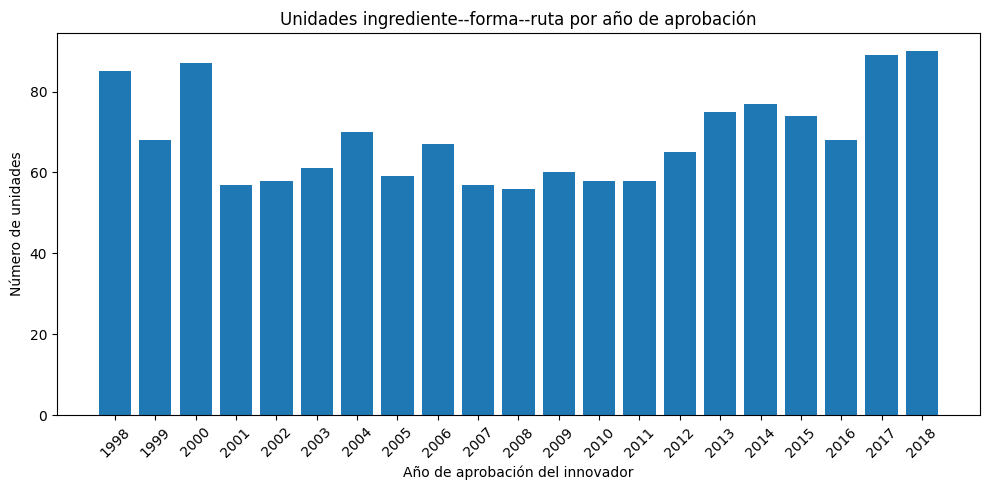

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/units_by_approval_year.png


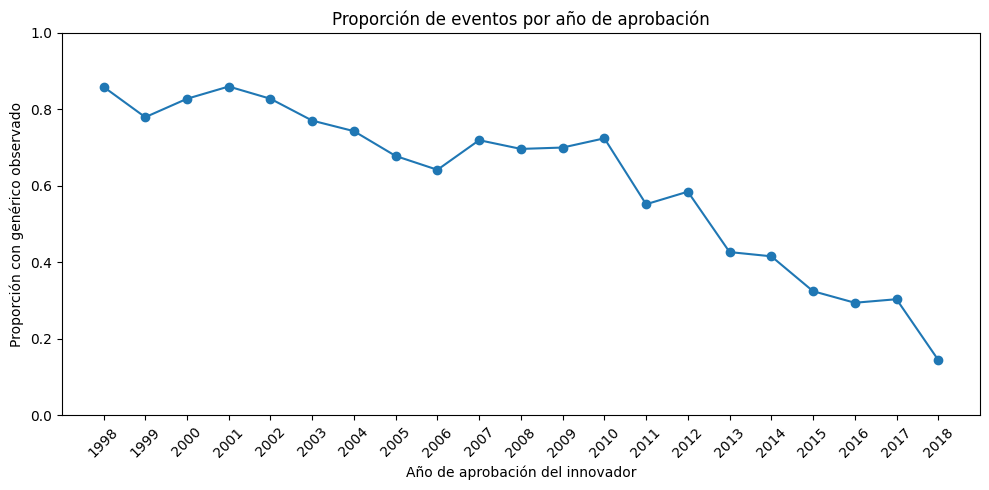

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/event_rate_by_approval_year.png


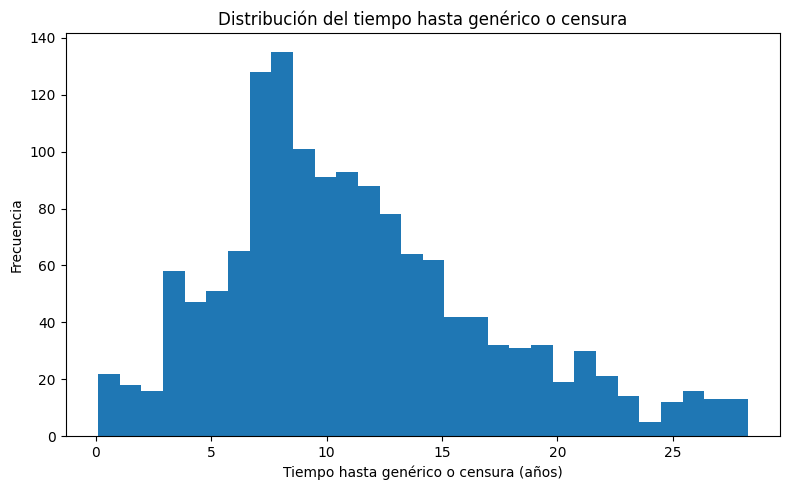

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/time_to_generic_or_censoring_hist.png


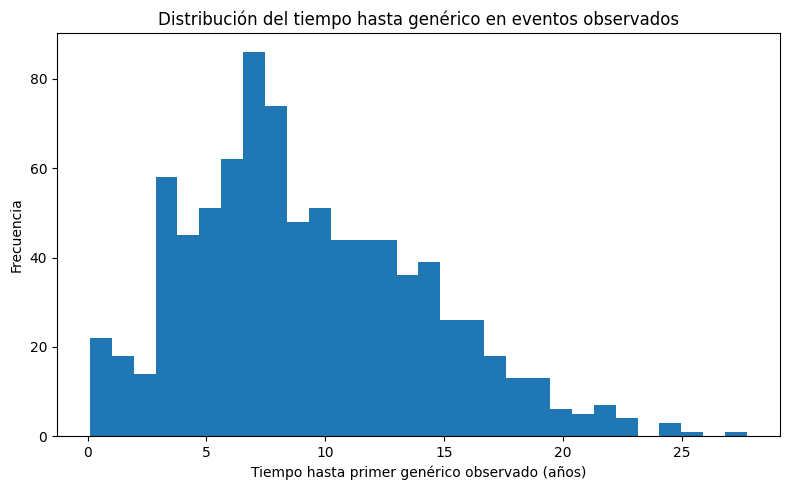

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/time_to_generic_events_only_hist.png


In [20]:
import matplotlib.pyplot as plt

# Asegurar que la carpeta de figuras exista
FIGURES_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Figura 1: número de unidades por año de aprobación
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(year_summary["approval_year"], year_summary["n_units"])
ax.set_xlabel("Año de aprobación del innovador")
ax.set_ylabel("Número de unidades")
ax.set_title("Unidades ingrediente--forma--ruta por año de aprobación")
ax.set_xticks(year_summary["approval_year"])
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig_path = FIGURES_DIR / "units_by_approval_year.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")


# ------------------------------------------------------------
# Figura 2: proporción de eventos por año de aprobación
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(year_summary["approval_year"], year_summary["event_rate"], marker="o")
ax.set_xlabel("Año de aprobación del innovador")
ax.set_ylabel("Proporción con genérico observado")
ax.set_title("Proporción de eventos por año de aprobación")
ax.set_ylim(0, 1)
ax.set_xticks(year_summary["approval_year"])
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig_path = FIGURES_DIR / "event_rate_by_approval_year.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")


# ------------------------------------------------------------
# Figura 3: tiempo hasta genérico o censura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(survival_analysis_v1["time_to_generic_years"], bins=30)
ax.set_xlabel("Tiempo hasta genérico o censura (años)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del tiempo hasta genérico o censura")

plt.tight_layout()
fig_path = FIGURES_DIR / "time_to_generic_or_censoring_hist.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")


# ------------------------------------------------------------
# Figura 4: tiempo hasta genérico en eventos observados
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

events_only = survival_analysis_v1.loc[
    survival_analysis_v1["event"].eq(1),
    "time_to_generic_years"
]

ax.hist(events_only, bins=30)
ax.set_xlabel("Tiempo hasta primer genérico observado (años)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución del tiempo hasta genérico en eventos observados")

plt.tight_layout()
fig_path = FIGURES_DIR / "time_to_generic_events_only_hist.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")

Las figuras permiten confirmar varios patrones importantes de la base preliminar.

La figura de unidades por año de aprobación muestra que la cohorte tiene observaciones distribuidas en todo el periodo 1998--2018. Aunque hay variación anual, no se observa un año completamente vacío, por lo que la ventana temporal seleccionada es adecuada para una primera exploración.

La figura de proporción de eventos por año de aprobación muestra una disminución clara en los años más recientes. Este patrón es esperable: los productos aprobados en 1998--2004 han tenido muchos más años de seguimiento hasta la fecha de corte de 2026, mientras que los aprobados en 2015--2018 han tenido menos tiempo para observar la entrada de genéricos. Por esta razón, no conviene comparar directamente proporciones crudas entre años sin considerar la censura.

Los histogramas del tiempo hasta genérico muestran una distribución amplia y asimétrica. Entre las unidades con evento observado, la mayor concentración ocurre aproximadamente entre 5 y 12 años, aunque existen eventos tempranos y eventos tardíos. Esto es compatible con la lógica regulatoria del problema, donde los tiempos hasta entrada genérica pueden depender de exclusividades, patentes, formulación, mercado y estrategias regulatorias.

El histograma del tiempo hasta genérico o censura incluye tanto eventos como observaciones censuradas, por lo que muestra tiempos más largos asociados a productos que no tuvieron genérico observado hasta la fecha de corte. Esto refuerza la necesidad de usar métodos de supervivencia, como Kaplan--Meier, en lugar de analizar solo promedios o histogramas.

En conjunto, estas visualizaciones indican que el dataset piloto es funcional y que el siguiente paso natural es estimar la curva Kaplan--Meier global.

## 16. Curva Kaplan--Meier global

Después de la exploración descriptiva, estimaremos la primera curva Kaplan--Meier global.

La curva Kaplan--Meier estima la función de supervivencia:

$$
S(t) = P(T > t),
$$

donde $T$ representa el tiempo desde la aprobación del innovador candidato hasta la entrada del primer genérico comparable.

En este contexto, $S(t)$ puede interpretarse como la probabilidad estimada de que una unidad ingrediente--forma--ruta todavía no tenga genérico comparable después de $t$ años desde su aprobación inicial.

La ventaja de Kaplan--Meier es que permite incorporar adecuadamente las observaciones censuradas. Es decir, productos que no tienen genérico observado hasta la fecha de corte todavía aportan información hasta el momento en que son censurados.

En la siguiente celda se hará lo siguiente:

- verificar si la librería `lifelines` está instalada;
- ajustar una curva Kaplan--Meier global;
- graficar la función de supervivencia;
- calcular algunos valores de supervivencia estimada a 5, 10, 15 y 20 años;
- guardar la figura en la carpeta `figures/`.

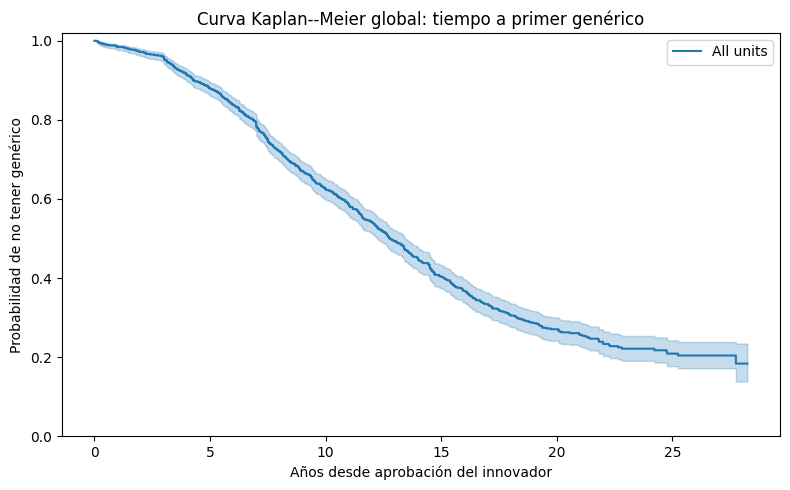

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/km_global_time_to_generic.png

Supervivencia estimada en tiempos seleccionados:
   time_years  survival_probability  probability_generic_by_t
0           5              0.879083                  0.120917
1          10              0.626227                  0.373773
2          15              0.404237                  0.595763
3          20              0.270477                  0.729523

Mediana Kaplan--Meier del tiempo a genérico:
12.791238877481177


In [23]:
try:
    from lifelines import KaplanMeierFitter
except ImportError as e:
    raise ImportError(
        "La librería 'lifelines' no está instalada. "
        "Instálala con: pip install lifelines"
    ) from e


# Datos para Kaplan--Meier
T = survival_analysis_v1["time_to_generic_years"]
E = survival_analysis_v1["event"]

kmf = KaplanMeierFitter()
kmf.fit(
    durations=T,
    event_observed=E,
    label="All units"
)

# Graficar curva KM
fig, ax = plt.subplots(figsize=(8, 5))

kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Años desde aprobación del innovador")
ax.set_ylabel("Probabilidad de no tener genérico")
ax.set_title("Curva Kaplan--Meier global: tiempo a primer genérico")
ax.set_ylim(0, 1.02)

plt.tight_layout()
fig_path = FIGURES_DIR / "km_global_time_to_generic.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")

# Supervivencia estimada en tiempos específicos
times_to_report = [5, 10, 15, 20]

km_summary = pd.DataFrame({
    "time_years": times_to_report,
    "survival_probability": [
        float(kmf.survival_function_at_times(t).iloc[0])
        for t in times_to_report
    ]
})

km_summary["probability_generic_by_t"] = 1 - km_summary["survival_probability"]

print("\nSupervivencia estimada en tiempos seleccionados:")
print(km_summary)

print("\nMediana Kaplan--Meier del tiempo a genérico:")
print(kmf.median_survival_time_)

La curva Kaplan--Meier global se estimó correctamente para la base `survival_analysis_v1`.

En esta figura, la función de supervivencia $S(t)$ representa la probabilidad estimada de que una unidad ingrediente--forma--ruta todavía no tenga un genérico comparable después de $t$ años desde la aprobación del innovador candidato.

Los resultados principales fueron:

- A los 5 años, la probabilidad estimada de no tener genérico es aproximadamente 0.879. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 12.1%.
- A los 10 años, la probabilidad estimada de no tener genérico es aproximadamente 0.626. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 37.4%.
- A los 15 años, la probabilidad estimada de no tener genérico es aproximadamente 0.404. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 59.6%.
- A los 20 años, la probabilidad estimada de no tener genérico es aproximadamente 0.270. Esto equivale a una probabilidad acumulada de entrada genérica de aproximadamente 73.0%.

La mediana Kaplan--Meier del tiempo a genérico fue de aproximadamente 12.79 años. Esto significa que, bajo esta definición preliminar de cohorte y emparejamiento, se estima que el 50% de las unidades tendría un genérico comparable alrededor de 12.8 años después de la aprobación inicial del innovador.

La curva muestra una caída progresiva, especialmente entre aproximadamente 7 y 16 años, lo cual sugiere que una parte importante de la entrada genérica ocurre después de los primeros años de protección regulatoria y comercial.

Es importante recordar que esta es una estimación preliminar. La interpretación final dependerá de refinar la definición de innovador, distinguir productos realmente NME de reformulaciones o nuevas presentaciones, e incorporar variables de patentes y exclusividades.